In [1]:
import os
import sys
import subprocess

def setup_dl_env():
    env_name = "dl_env"
    env_dir = os.path.join(os.getcwd(), env_name)
    
    print("Verifying virtual environment...")
    
    if not os.path.exists(env_dir):
        print(f"Creating virtual environment '{env_name}'...")
        subprocess.check_call([sys.executable, "-m", "venv", env_name])
        print(f"Virtual environment '{env_name}' created.")
    else:
        print(f"Virtual environment '{env_name}' already exists.")
        
    print(f"Current executable: {sys.executable}")
    if env_name not in sys.executable:
        print(f"\nWARNING: The current kernel is NOT using the '{env_name}' environment.")
        print("Please activate the environment before running the rest of the code.")
    else:
        print(f"Success! Running inside '{env_name}' environment.")

setup_dl_env()

Verifying virtual environment...
Virtual environment 'dl_env' already exists.
Current executable: C:\AI-Projects\MyAI\DL\dl_env\Scripts\python.exe
Success! Running inside 'dl_env' environment.


# Deep Reinforcement Learning
Reinforcement Learning (RL) trains an agent to make sequences of decisions in an environment to maximize cumulative reward. Deep RL combines RL with deep neural networks to handle high-dimensional state spaces (images, raw sensor data).

## 1. Core RL Framework
**Key components:**
- **Agent**: The learner who takes actions
- **Environment**: The world the agent interacts with
- **State (s)**: Current observation of the environment
- **Action (a)**: The decision the agent makes
- **Reward (r)**: Scalar feedback signal from the environment
- **Policy (pi)**: The agent's behavior — maps states to actions
- **Value Function V(s)**: Expected cumulative reward starting from state s following policy pi
- **Q-Function Q(s,a)**: Expected cumulative reward starting from state s, taking action a, then following pi

**Goal**: Find the optimal policy pi* that maximizes expected cumulative discounted reward: E[sum gamma^t * r_t]
where gamma (discount factor, 0 < gamma <= 1) weights future rewards less than immediate rewards.

## 2. Markov Decision Process (MDP)
RL is formalized as an MDP (S, A, P, R, gamma):
- S: state space, A: action space
- P(s'|s,a): transition probability (environment dynamics)
- R(s,a): reward function
- gamma: discount factor

**Markov Property**: The next state depends only on the current state and action, not on history.

## 3. Deep Q-Network (DQN)
DeepMind played Atari games at superhuman level using only raw pixels as input.

**Key components:**
- A CNN processes raw game screen pixels → Q-values for each action
- **Experience Replay Buffer**: Stores (s, a, r, s') transitions; samples random mini-batches for training (breaks temporal correlations)
- **Target Network**: A separate, slowly updated copy of the Q-network used to compute stable TD targets (prevents oscillating updates)
- **Loss**: L = E[(r + gamma * max_a Q_target(s', a) - Q(s, a))^2]

**Key DQN improvements:**
- Double DQN: separates action selection and evaluation to reduce overestimation bias
- Dueling DQN: separate streams for V(s) and advantage A(s,a)
- Prioritized Experience Replay: sample transitions with higher TD error more frequently

In [2]:
import tensorflow as tf
from tensorflow.keras import layers, models
from collections import deque
import numpy as np

class DQNNetwork(tf.keras.Model):
    def __init__(self, state_dim, action_dim):
        super().__init__()
        self.dense1 = layers.Dense(256, activation='relu')
        self.dense2 = layers.Dense(256, activation='relu')
        self.q_values = layers.Dense(action_dim)

    def call(self, states):
        x = self.dense1(states)
        x = self.dense2(x)
        return self.q_values(x)

class ReplayBuffer:
    def __init__(self, capacity=50000):
        self.buffer = deque(maxlen=capacity)

    def push(self, state, action, reward, next_state, done):
        self.buffer.append((state, action, reward, next_state, done))

    def sample(self, batch_size):
        idx = np.random.choice(len(self.buffer), batch_size, replace=False)
        batch = [self.buffer[i] for i in idx]
        return zip(*batch)

# Initialize
state_dim, action_dim = 8, 4
q_net = DQNNetwork(state_dim, action_dim)
target_net = DQNNetwork(state_dim, action_dim)
buffer = ReplayBuffer()
print("DQN components initialized. Q-net, Target-net, and Replay Buffer ready.")


[TensorFlow DLL Diagnostic] Analyzing: C:\AI-Projects\MyAI\DL\dl_env\Lib\site-packages\tensorflow\python\_pywrap_tensorflow_internal.pyd


[Error] Failed to load _pywrap_tensorflow_common.dll: INITIALIZATION FAILED (0x45A) - The DLL's DllMain returned false.
    Hint: This often happens if your CPU lacks required instructions (like AVX/AVX2)
    or if the Microsoft Visual C++ Redistributable is outdated/missing.


ImportError: Traceback (most recent call last):
  File "C:\AI-Projects\MyAI\DL\dl_env\Lib\site-packages\tensorflow\python\pywrap_tensorflow.py", line 74, in <module>
    from tensorflow.python._pywrap_tensorflow_internal import *
ImportError: DLL load failed while importing _pywrap_tensorflow_internal: A dynamic link library (DLL) initialization routine failed.


Failed to load the native TensorFlow runtime.
See https://www.tensorflow.org/install/errors for some common causes and solutions.
If you need help, create an issue at https://github.com/tensorflow/tensorflow/issues and include the entire stack trace above this error message.

## 4. Policy Gradient Methods (REINFORCE)
Instead of learning Q-values, directly optimize the policy parameters theta to maximize expected return.

**REINFORCE Algorithm:**
1. Run episode with current policy, collect trajectories (s, a, r)
2. Compute discounted returns G_t = sum_{k=t}^T gamma^(k-t) * r_k
3. Update: theta <- theta + alpha * sum_t G_t * grad_theta log pi_theta(a_t|s_t)

The gradient log pi(a|s) is called the **score function** — it points in the direction that makes the taken action more probable, weighted by how good the outcome was.

**Limitation**: High variance in gradient estimates due to full Monte Carlo returns.

## 5. Actor-Critic Methods (A2C/A3C)
Combine value-based (Critic) and policy-based (Actor) approaches:
- **Actor**: Policy pi_theta(a|s) — takes actions
- **Critic**: Value function V_w(s) — evaluates how good the state is
- Use **advantage** A(s,a) = Q(s,a) - V(s) to reduce variance
- **A3C**: Asynchronous agents run in parallel to collect diverse experience

## 6. Proximal Policy Optimization (PPO)
The most widely used practical RL algorithm.

**Key idea**: Clip the policy update to stay within a trust region, preventing catastrophically large policy changes.

PPO-Clip objective:
```
L = E[min(r_t * A_t, clip(r_t, 1-epsilon, 1+epsilon) * A_t)]
r_t = pi_theta(a|s) / pi_theta_old(a|s)    [probability ratio]
```

Advantages of PPO:
- More stable than REINFORCE and A3C
- Sample efficient for continuous action spaces
- Simple to implement; used in OpenAI Five, ChatGPT RLHF training

In [3]:
# PPO Key Components (conceptual implementation sketch)

import tensorflow as tf
import tensorflow_probability as tfp

class ActorCritic(tf.keras.Model):
    def __init__(self, state_dim, action_dim):
        super().__init__()
        self.shared = tf.keras.Sequential([
            layers.Dense(256, activation='relu'),
            layers.Dense(256, activation='relu')
        ])
        self.actor = layers.Dense(action_dim)    # Logits for discrete actions
        self.critic = layers.Dense(1)             # State value estimate

    def call(self, states):
        x = self.shared(states)
        return self.actor(x), self.critic(x)

    def get_action(self, state):
        logits, value = self(state[None, :])
        dist = tfp.distributions.Categorical(logits=logits)
        action = dist.sample()
        log_prob = dist.log_prob(action)
        return action.numpy()[0], log_prob.numpy()[0], value.numpy()[0, 0]

def ppo_clip_loss(old_log_probs, new_log_probs, advantages, epsilon=0.2):
    ratio = tf.exp(new_log_probs - old_log_probs)
    clipped = tf.clip_by_value(ratio, 1-epsilon, 1+epsilon)
    return -tf.reduce_mean(tf.minimum(ratio * advantages, clipped * advantages))

print("PPO Actor-Critic and clipped loss defined.")


[TensorFlow DLL Diagnostic] Analyzing: C:\AI-Projects\MyAI\DL\dl_env\Lib\site-packages\tensorflow\python\_pywrap_tensorflow_internal.pyd


[Error] Failed to load _pywrap_tensorflow_common.dll: INITIALIZATION FAILED (0x45A) - The DLL's DllMain returned false.
    Hint: This often happens if your CPU lacks required instructions (like AVX/AVX2)
    or if the Microsoft Visual C++ Redistributable is outdated/missing.


ImportError: Traceback (most recent call last):
  File "C:\AI-Projects\MyAI\DL\dl_env\Lib\site-packages\tensorflow\python\pywrap_tensorflow.py", line 74, in <module>
    from tensorflow.python._pywrap_tensorflow_internal import *
ImportError: DLL load failed while importing _pywrap_tensorflow_internal: A dynamic link library (DLL) initialization routine failed.


Failed to load the native TensorFlow runtime.
See https://www.tensorflow.org/install/errors for some common causes and solutions.
If you need help, create an issue at https://github.com/tensorflow/tensorflow/issues and include the entire stack trace above this error message.

# Conclusions and Key Takeaways
- RL is the framework for sequential decision-making; Deep RL replaces tabular representations with neural networks.
- **DQN** was the breakthrough that proved deep RL could handle raw sensory input at superhuman levels.
- **Policy Gradients** (REINFORCE) directly optimize the policy but suffer high variance.
- **Actor-Critic** methods combine the best of both by using a critic to reduce gradient variance.
- **PPO** achieves the best balance of stability, sample efficiency, and simplicity for most practical tasks.

# Pros and Cons
**Pros:**
- RL can solve problems with no labeled data — reward signal is the only supervision
- Achieves superhuman performance in games, robotics, and chip design (AlphaGo, AlphaStar)
- PPO works well across diverse tasks without heavy hyperparameter tuning

**Cons:**
- Extremely sample inefficient — requires millions of environment interactions to learn
- Reward shaping is notoriously difficult; sparse rewards lead to very slow learning
- Prone to catastrophic forgetting and local optima
- Simulation-to-real-world transfer remains a major open challenge

# 15 Interview Questions and Answers

1. **What is the difference between model-free and model-based RL?**
   *Answer*: Model-free learns a policy or value function directly from experience without learning environment dynamics. Model-based explicitly learns a model of the environment (T(s,a)->s', R(s,a)) that it can use for planning (e.g., AlphaZero MCTS).

2. **What are the Bellman equations?**
   *Answer*: Recursive equations defining the optimal value functions: V*(s) = max_a [R(s,a) + gamma * sum P(s'|s,a) * V*(s')]; similarly for Q*. Used as the basis for Q-learning and TD algorithms.

3. **What is the Exploration-Exploitation Dilemma?**
   *Answer*: The agent must balance exploiting known good actions vs exploring new actions that might yield better long-term rewards. Common strategies: epsilon-greedy (randomly explore with probability epsilon), UCB, Thompson Sampling.

4. **What is experience replay in DQN and why is it used?**
   *Answer*: A memory buffer that stores past (s, a, r, s') transitions. Training samples random mini-batches from this buffer, breaking temporal correlation between consecutive samples and improving data efficiency.

5. **What is the Target Network in DQN?**
   *Answer*: A separate copy of the Q-network with parameters updated slowly (every C steps). Using it to compute TD targets prevents the "chasing a moving target" instability that occurs when the same network computes both predictions and targets.

6. **What is the Advantage function A(s,a)?**
   *Answer*: A(s,a) = Q(s,a) - V(s). It measures how much better action a is than the average action in state s. Using advantage instead of raw Q-values reduces variance in policy gradient estimates.

7. **What is the difference between on-policy and off-policy learning?**
   *Answer*: On-policy (REINFORCE, PPO): learns about the current policy from data generated by that same policy. Off-policy (DQN, SAC): can learn from data generated by a different (potentially older) policy, enabling replay buffers.

8. **Why is PPO considered more stable than vanilla Policy Gradients?**
   *Answer*: By clipping the probability ratio r_t to stay within [1-epsilon, 1+epsilon], PPO prevents overly large policy updates that could catastrophically change behavior and destabilize training.

9. **What is the reward discount factor (gamma) and what happens at extremes?**
   *Answer*: Gamma balances immediate vs future rewards. Gamma=0: myopic, only cares about immediate reward. Gamma=1: values long-term return equally to immediate; can cause instability with infinite horizons.

10. **What is AlphaGo's key innovation over traditional game AI?**
    *Answer*: Using a policy network (to guide MCTS search) and a value network (to estimate position value) trained by self-play. It reduced the search space from exponential to tractable while achieving superhuman Go play.

11. **What is the difference between Q-learning and SARSA?**
    *Answer*: Q-learning (off-policy): updates using max Q(s', a') regardless of the actual next action taken. SARSA (on-policy): updates using Q(s', a') for the actual next action a' chosen by the current policy.

12. **What is Soft Actor-Critic (SAC)?**
    *Answer*: An off-policy, maximum entropy RL algorithm for continuous action spaces. It maximizes both reward and policy entropy simultaneously (incentivizing exploration), achieving state-of-the-art sample efficiency on continuous control benchmarks.

13. **How is RLHF used to train Large Language Models?**
    *Answer*: (1) Collect human preference rankings of model outputs. (2) Train a Reward Model on these preferences. (3) Use PPO to fine-tune the LLM with the learned reward signal, aligning generation with human preferences.

14. **What is curriculum RL?**
    *Answer*: Progressively increasing task difficulty during training. Starting with simpler environments (closer goal, fewer obstacles) and gradually increasing difficulty helps the agent bootstrap from solvable tasks rather than facing sparse reward from the start.

15. **What is the credit assignment problem in RL?**
    *Answer*: When a sequence of many actions leads to a final reward, it is difficult to determine which specific actions were responsible for the outcome. This is especially challenging with sparse, delayed rewards over long episodes.


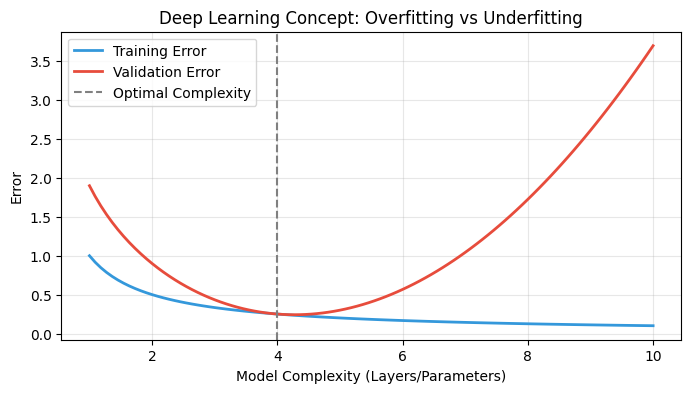

In [4]:
import matplotlib.pyplot as plt
import numpy as np

# Generic Concept Visualization: Model Complexity vs Error
capacity = np.linspace(1, 10, 100)
train_error = 1 / capacity
val_error = 1/capacity + 0.1 * (capacity - 4)**2

plt.figure(figsize=(8, 4))
plt.plot(capacity, train_error, label='Training Error', color='#3498db', lw=2)
plt.plot(capacity, val_error, label='Validation Error', color='#e74c3c', lw=2)
plt.axvline(4, color='gray', linestyle='dashed', label='Optimal Complexity')
plt.title('Deep Learning Concept: Overfitting vs Underfitting')
plt.xlabel('Model Complexity (Layers/Parameters)')
plt.ylabel('Error')
plt.legend(); plt.grid(True, alpha=0.3)
plt.show()